In [14]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_excel("group-c-dataset.xlsx")
print("Dataset shape:", df.describe())
print(df.shape)

Dataset shape:        TOTAL NO OF PEOPLE   TOTAL NO OF LAPTOPS  PRESSURE HPA  CLASS SESSION  \
count           19.000000             19.000000     19.000000      19.000000   
mean            12.631579              8.210526   1004.581579       0.315789   
std              8.712765              5.553567      6.644500       0.477567   
min              2.000000              2.000000    994.000000       0.000000   
25%              5.500000              3.000000    998.500000       0.000000   
50%             12.000000             10.000000   1008.000000       0.000000   
75%             19.000000             11.500000   1010.105000       1.000000   
max             30.000000             20.000000   1012.000000       1.000000   

       AC TEMPERATURE  WINDSPEED MPH  FANS RUNNING  \
count       19.000000      19.000000     19.000000   
mean        10.947368       6.368421      1.947368   
std          7.641071       1.630628      1.311220   
min          0.000000       3.000000      0.0000

In [15]:

# Define features and target
X = df.drop("AVERAGE TEMPERATURE",axis=1)
y = df["AVERAGE TEMPERATURE"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)



Model Evaluation:
MSE: 0.23747027432553777
RMSE: 0.48730921838760427
R2 Score: 0.9713026858821102


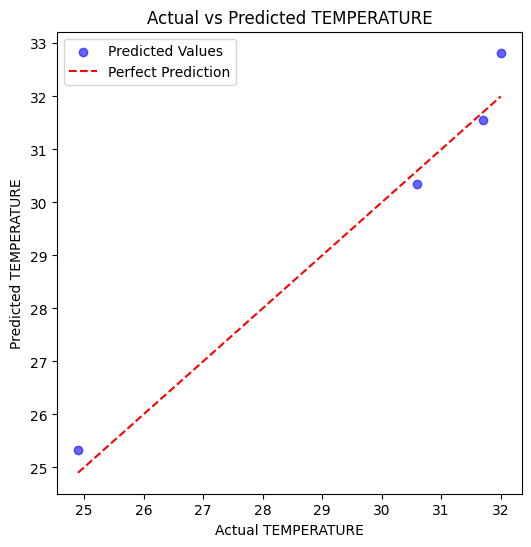

In [16]:

# Graphical Representation of Predicted Prices against Actual Prices
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
# Scatter points
plt.scatter(y_test, y_pred, color="blue", alpha=0.6, label="Predicted Values")
# Ideal line (perfect prediction)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)
plt.xlabel("Actual TEMPERATURE")
plt.ylabel("Predicted TEMPERATURE")
plt.title("Actual vs Predicted TEMPERATURE")
plt.legend()
plt.show()